# Mooooodellllll

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import warnings
import holidays
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error


import pickle
from pathlib import Path
import re

import shap

# Linear
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)

# Tree / Ensemble
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# Boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from datetime import datetime

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

model_dir = Path("saved_models")
model_dir.mkdir(exist_ok=True)

shap_dir = Path("shap_outputs")
shap_dir.mkdir(exist_ok=True)

In [2]:
def read_sheets(filename):
    """Read the input data"""
    sheets = pd.read_excel(filename, sheet_name=None)
    df = pd.concat(sheets.values(), ignore_index=True)
    return df.shape, df

df_time_shape, df_time = read_sheets("time_card_daily_latest.xlsx")
print(f"Time shape: {df_time_shape}")

Time shape: (131036, 16)


## ABT Build

In [3]:
task_types = ["INC", "CHG", "SCT"]

df_time["is_sick_or_holiday"] = df_time["Category"].isin(["Sick/Holiday"]).astype(int)

df_time = df_time[
    df_time["Task"].str.startswith(tuple(task_types), na=False)
    | df_time["Category"].isin(["Sick/Holiday"])
]

In [4]:
df_time["Date"] = pd.to_datetime(df_time["Date"])

In [5]:
print(df_time["Date"].max())

2026-07-03 00:00:00


In [6]:
df_time["Category"].value_counts()

Category
Task work       58352
Sick/Holiday     5127
Name: count, dtype: int64

## Feature Engineering - Demand 

* Note that the ABT will be different depending on the model. This notebook only contains the DEMAND models.

In [7]:
abt = df_time.drop(
    ["Task", "Category", "User ID", "Rate type",
     "Additional comments", "Grade", "Business Services",
     "Short description", "Company", "Business service", "Project ID", "User"], axis=1)
abt.head(3)

,Date,Technology,Time worked,Specialisation,is_sick_or_holiday
0,2024-05-01,Dynamics 365 FO,1.0,NaN,0
3,2024-05-01,Dynamics 365 FO,0.5,NaN,0
4,2024-05-01,Dynamics 365 FO,1.0,NaN,0


In [8]:
def one_hot_encode(df, columns, drop_first=False, dummy_na=False, dtype="int"):
    df_encoded = pd.get_dummies(
        df,
        columns=columns,
        drop_first=drop_first,
        dummy_na=dummy_na
    )
    dummy_cols = [col for col in df_encoded.columns 
                  if any(col.startswith(f"{c}_") for c in columns)]
    
    df_encoded[dummy_cols] = df_encoded[dummy_cols].astype(dtype)

    return df_encoded

abt_encoded = abt.copy()
abt_encoded["Date"] = pd.to_datetime(abt_encoded["Date"])
abt_encoded = abt_encoded.sort_values(by="Date", ascending=True)
abt_encoded.head(3)

,Date,Technology,Time worked,Specialisation,is_sick_or_holiday
0,2024-05-01,Dynamics 365 FO,1.0,NaN,0
40,2024-05-01,Dynamics 365 CE,4.0,NaN,0
43,2024-05-01,NaN,8.0,CE Technical,1


In [9]:
abt_encoded.Specialisation.notna().value_counts()

Specialisation
True     54873
False     8606
Name: count, dtype: int64

In [10]:
abt_encoded["Specialisation"] = (
    abt_encoded["Specialisation"]
    .fillna(abt_encoded["Specialisation"].mode().iloc[0])
)

abt_encoded["Technology"] = (
    abt_encoded["Technology"]
    .fillna(abt_encoded["Technology"].mode().iloc[0])
)

In [11]:
abt_encoded.Technology.notna().value_counts()

Technology
True    63479
Name: count, dtype: int64

In [12]:
grouped_dfs = {}

for (spec, tech), group in abt_encoded.groupby(["Specialisation", "Technology"]):
    key = f"{spec}_{tech}".replace(" ", "_")
    grouped_dfs[key] = group.copy()

In [13]:
def aggregate_df(
    df,
    spike_dates=None,
    dip_dates=None,
    holiday_dates=None
):

    df = df.copy()

    df["Date"] = pd.to_datetime(df["Date"])

    df["week"] = df["Date"].dt.to_period("W").dt.start_time

    df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
    df["month"] = df["week"].dt.month
    df["is_month_end"] = df["week"].dt.is_month_end.astype(int)
    df["is_quarter_end"] = df["week"].dt.is_quarter_end.astype(int)

    # Spike flag
    if spike_dates is not None:
        spike_dates = pd.to_datetime(spike_dates)
        df["is_spike"] = (
            df["Date"].dt.normalize().isin(spike_dates)
        ).astype(int)
    else:
        df["is_spike"] = 0

    # Dip flag
    if dip_dates is not None:
        dip_dates = pd.to_datetime(dip_dates)
        df["is_dip"] = (
            df["Date"].dt.normalize().isin(dip_dates)
        ).astype(int)
    else:
        df["is_dip"] = 0

    # Holiday flag
    if holiday_dates is not None:
        holiday_dates = pd.to_datetime(holiday_dates)
        df["is_holiday"] = (
            df["Date"].dt.normalize().isin(holiday_dates)
        ).astype(int)
    else:
        df["is_holiday"] = 0

    # Numeric columns containing underscores
    underscore_cols = [
        col
        for col in df.columns
        if "_" in col and pd.api.types.is_numeric_dtype(df[col])
    ]

    # Avoid duplicates
    underscore_cols = [
        c for c in underscore_cols
        if c not in ["is_spike", "is_dip", "is_holiday"]
    ]

    agg_cols = [
        "Time worked",
        "is_spike",
        "is_dip",
        "is_holiday",
        *underscore_cols,
    ]

    weekly_df = (
        df.groupby("week")[agg_cols]
        .sum()
        .reset_index()
        .sort_values("week")
    )

    weekly_df["week_of_year"] = (
        weekly_df["week"].dt.isocalendar().week.astype(int)
    )
    weekly_df["month"] = weekly_df["week"].dt.month
    weekly_df["is_month_end"] = weekly_df["week"].dt.is_month_end.astype(int)
    weekly_df["is_quarter_end"] = weekly_df["week"].dt.is_quarter_end.astype(int)

    weekly_df["is_holiday"] = (
        weekly_df["is_holiday"] > 0
    ).astype(int)

    weekly_df = weekly_df[
        ~(
            (weekly_df["week"].dt.year == 2026)
            & (weekly_df["week"].dt.month.isin([6, 7]))
        )
    ]

    return weekly_df

In [14]:
mt_holidays = holidays.MT(years=[2024, 2025, 2026])
uk_holidays = holidays.UK(years=[2024, 2025, 2026])

holiday_dates = list(
    set(mt_holidays.keys()) | set(uk_holidays.keys())
)


for i in grouped_dfs:
    grouped_dfs[i] = aggregate_df(grouped_dfs[i], spike_dates=None, holiday_dates=holiday_dates)

In [19]:
import pandas as pd

def fill_missing_weeks(
    weekly_df: pd.DataFrame,
    global_start: pd.Timestamp,
    global_end: pd.Timestamp,
    time_col: str = "Time worked",
    freq: str = "W-MON",
) -> pd.DataFrame:
    """
    weekly_df: output from aggregate_df, with a 'week' column (datetime at week start)
    time_col: column to fill with 0 for missing weeks
    freq: week frequency, e.g. 'W-MON' or 'W-SUN'
    global_start: global start date (e.g. '2024-01-01' or pd.Timestamp('2024-01-01'))
    global_end: global end date (e.g. '2026-12-31' or pd.Timestamp('2026-12-31'))
    """
    weekly_df = weekly_df.copy()

    # Ensure week is datetime and sorted
    weekly_df["week"] = pd.to_datetime(weekly_df["week"])
    weekly_df = weekly_df.sort_values("week").reset_index(drop=True)

    # Use global range if provided, otherwise use dataframe range
    start = pd.to_datetime(global_start) if global_start is not None else weekly_df["week"].min()
    end = pd.to_datetime(global_end) if global_end is not None else weekly_df["week"].max()

    full_range = pd.date_range(start=start, end=end, freq=freq)

    # Set week as index, reindex to full range, fill missing with 0 for time_col
    weekly_df_idx = weekly_df.set_index("week")
    weekly_df_complete = weekly_df_idx.reindex(full_range, fill_value=0)

    # If you want to avoid fill_value=0 and fill only time_col later:
    # weekly_df_complete = weekly_df_idx.reindex(full_range)
    # weekly_df_complete[time_col] = weekly_df_complete[time_col].fillna(0)

    weekly_df_complete = weekly_df_complete.reset_index()
    weekly_df_complete = weekly_df_complete.rename(columns={"index": "week"})

    return weekly_df_complete

In [16]:
def flag_weekly_spikes_dips_rolling_preceding(
    weekly_df: pd.DataFrame,
    time_col: str = "Time worked",
    threshold_pct: float = 0.40,
    window: int = 2,
    baseline: str = "median",
    min_periods: int = 2  # require at least 2 preceding weeks
) -> pd.DataFrame:
    weekly_df = weekly_df.copy()
    weekly_df = weekly_df.sort_values("week").reset_index(drop=True)

    if baseline == "median":
        rolling_base = weekly_df[time_col].rolling(window=window, min_periods=min_periods).median()
    elif baseline == "mean":
        rolling_base = weekly_df[time_col].rolling(window=window, min_periods=min_periods).mean()
    else:
        raise ValueError("baseline must be 'median' or 'mean'")

    # Shift: baseline uses only preceding weeks
    rolling_base = rolling_base.shift(1)

    lower = rolling_base * (1 - threshold_pct)
    upper = rolling_base * (1 + threshold_pct)

    # Only flag when baseline exists (i.e., there are enough preceding weeks)
    weekly_df["is_dip"] = (
        (lower.notna()) & (weekly_df[time_col] < lower)
    ).astype(int)

    weekly_df["is_spike"] = (
        (upper.notna()) & (weekly_df[time_col] > upper)
    ).astype(int)

    return weekly_df

### Manually identify weeks with spikes and dips in the ABT

In [20]:
def get_global_start_end(grouped_dfs: dict, date_col: str = "week"):
    """
    Return (global_start, global_end) across all dataframes in grouped_dfs.
    
    grouped_dfs: dict-like of dataframes (e.g. {key: df})
    date_col: name of the date column in each dataframe
    """
    all_min = []
    all_max = []

    for name, df in grouped_dfs.items():
        dates = pd.to_datetime(df[date_col])
        all_min.append(dates.min())
        all_max.append(dates.max())

    global_start = min(all_min)
    global_end = max(all_max)

    return global_start, global_end

global_start, global_end = get_global_start_end(grouped_dfs)

In [22]:
for i in grouped_dfs:
    temp = grouped_dfs[i]
    if len(temp) > 3:
        temp = fill_missing_weeks(temp, global_start, global_end)
        temp = flag_weekly_spikes_dips_rolling_preceding(temp)
        grouped_dfs[i] = temp

## Model Selection

In [23]:
def get_models():

    return {

        "Ridge": (
            Ridge(),
            {"alpha": [0.01, 0.1, 1, 10]}
        ),

        "Lasso": (
            Lasso(),
            {"alpha": [0.01, 0.1, 1]}
        ),

        "ElasticNet": (
            ElasticNet(),
            {"alpha": [0.01, 0.1, 1]}
        ),

        "BayesianRidge": (
            BayesianRidge(),
            {
                "alpha_1": [1e-6, 1e-5],
                "lambda_1": [1e-6, 1e-5]
            }
        ),

        "Huber": (
            HuberRegressor(),
            {
                "epsilon": [1.1, 1.35, 1.5]
            }
        ),

        "DecisionTree": (
            DecisionTreeRegressor(),
            {
                "max_depth": [3, 5, 10]
            }
        ),

        "RandomForest": (
            RandomForestRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "max_depth": [3, 5, 10]
            }
        ),

        "ExtraTrees": (
            ExtraTreesRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500]
            }
        ),

        "GradientBoosting": (
            GradientBoostingRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "AdaBoost": (
            AdaBoostRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500]
            }
        ),

        "XGBoost": (
            XGBRegressor(random_state=42),
            {
                "n_estimators": [100, 200, 500],
                "max_depth": [3, 5],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "LightGBM": (
            LGBMRegressor(
                verbosity=-1,
                random_state=42
            ),
            {
                "n_estimators": [100, 200, 500],
                "num_leaves": [15, 31],
                "learning_rate": [0.05, 0.1]
            }
        ),

        "SVR": (
            SVR(),
            {
                "C": [0.1, 1, 10]
            }
        ),

        "KNN": (
            KNeighborsRegressor(),
            {
                "n_neighbors": [3, 5, 7]
            }
        )
    }

In [24]:
def build_features(df_group):

    df_group = df_group.copy()

    if "week" in df_group.columns:
        df_group = df_group.sort_values("week")

    df_group["lag_1"] = df_group["Time worked"].shift(1)
    df_group["lag_2"] = df_group["Time worked"].shift(2)
    df_group["rolling_4"] = (
        df_group["Time worked"]
        .rolling(4)
        .mean()
    )

    df_group = df_group.dropna()

    y = df_group["Time worked"]

    X = df_group.drop(
        columns=["Time worked", "week"],
        errors="ignore"
    )

    X = X.loc[:, X.nunique() > 1]

    return df_group, X, y

In [25]:
def find_best_model(
    group_name,
    X_train,
    X_test,
    y_train,
    y_test,
    n_obs
):

    results = []

    best_model = None
    best_preds = None
    best_mae = float("inf")
    best_mape = float("inf")
    best_name = None

    tscv = TimeSeriesSplit(n_splits=5)

    for name, (model, params) in get_models().items():

        try:

            search = RandomizedSearchCV(
                estimator=model,
                param_distributions=params,
                n_iter=20,
                cv=tscv,
                scoring="neg_mean_absolute_error",
                random_state=42,
                n_jobs=-1
            )

            search.fit(
                X_train,
                y_train
            )

            estimator = search.best_estimator_

            preds = estimator.predict(X_test)

            mae = mean_absolute_error(
                y_test,
                preds
            )

            mape = mean_absolute_percentage_error(
                y_test,
                preds
            )

            results.append({
                "group": group_name,
                "model": name,
                "MAE": mae,
                "MAPE": mape,
                "n_obs": n_obs,
                "best_params": search.best_params_
            })

            if mae < best_mae:

                best_model = estimator
                best_preds = preds
                best_mae = mae
                best_mape = mape
                best_name = name

        except Exception as e:

            print(
                f"{group_name} | {name} failed: {e}"
            )

    return (
        results,
        best_model,
        best_preds,
        best_name,
        best_mae,
        best_mape
    )

In [26]:
def plot_predictions(
    group_name,
    df_group,
    y,
    y_train,
    y_test,
    best_preds,
    best_name,
    best_mae,
    split_idx
):

    plt.figure(figsize=(12, 5))

    weeks = df_group["week"]

    plt.plot(
        weeks,
        y,
        label="Historical",
        alpha=0.4
    )

    plt.plot(
        weeks[:split_idx],
        y_train,
        label="Train"
    )

    plt.plot(
        weeks[split_idx:],
        y_test,
        label="Actual"
    )

    plt.plot(
        weeks[split_idx:],
        best_preds,
        linestyle="--",
        label=f"{best_name} Predicted"
    )

    plt.axvline(
        weeks.iloc[split_idx],
        color="black",
        linestyle=":"
    )

    plt.xticks(rotation=45)

    plt.title(
        f"{group_name} | {best_name} | MAE={best_mae:.2f}"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

In [27]:
def generate_xgb_explainability(
    group_name,
    X_train,
    y_train,
    shap_dir
):

    explain_model = XGBRegressor(
        random_state=42,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1
    )

    explain_model.fit(
        X_train,
        y_train
    )

    importance_df = pd.DataFrame({
        "group": group_name,
        "feature": X_train.columns,
        "importance": explain_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )

    sample_size = min(
        1000,
        len(X_train)
    )

    shap_sample = X_train.sample(
        sample_size,
        random_state=42
    )

    explainer = shap.TreeExplainer(
        explain_model
    )

    shap_values = explainer.shap_values(
        shap_sample
    )

    safe_name = re.sub(
        r"[^A-Za-z0-9_-]",
        "_",
        str(group_name)
    )

    shap.summary_plot(
        shap_values,
        shap_sample,
        show=False
    )

    plt.savefig(
        shap_dir /
        f"{safe_name}_shap_summary.png",
        bbox_inches="tight"
    )

    plt.close()

    shap.summary_plot(
        shap_values,
        shap_sample,
        plot_type="bar",
        show=False
    )

    plt.savefig(
        shap_dir /
        f"{safe_name}_shap_bar.png",
        bbox_inches="tight"
    )

    plt.close()

    return importance_df

In [32]:
def save_model(
    group_name,
    best_model,
    X,
    y,
    df_group,
    best_name,
    best_mae,
    best_mape,
    model_dir
):

    best_model.fit(X, y)

    parts = str(group_name).split("_")

    specialisation = "_".join(parts[:2])
    technology = "_".join(parts[2:])

    specialisation = re.sub(
        r"[^A-Za-z0-9_-]",
        "_",
        specialisation
    )

    technology = re.sub(
        r"[^A-Za-z0-9_-]",
        "_",
        technology
    )

    filename = (
        model_dir /
        f"{specialisation}__{technology}__{best_name}.pkl"
    )

    package = {
        "model": best_model,
        "features": list(X.columns),
        "history": (
            df_group["Time worked"]
            .tail(20)
            .tolist()
        ),
        "last_week": (
            df_group["week"]
            .max()
        ),
        "specialisation": specialisation,
        "technology": technology,
        "best_model_name": best_name,
        "mae": best_mae,
        "mape": best_mape
    }

    with open(filename, "wb") as f:
        pickle.dump(package, f)

    print(f"Saved: {filename}")

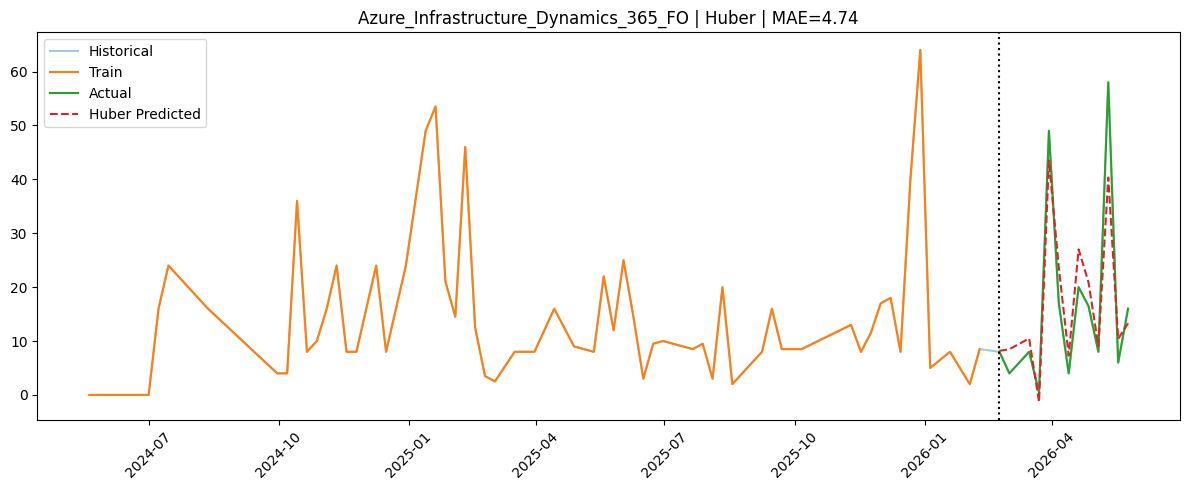

Saved: saved_models\Azure_Infrastructure__Dynamics_365_FO__Huber.pkl


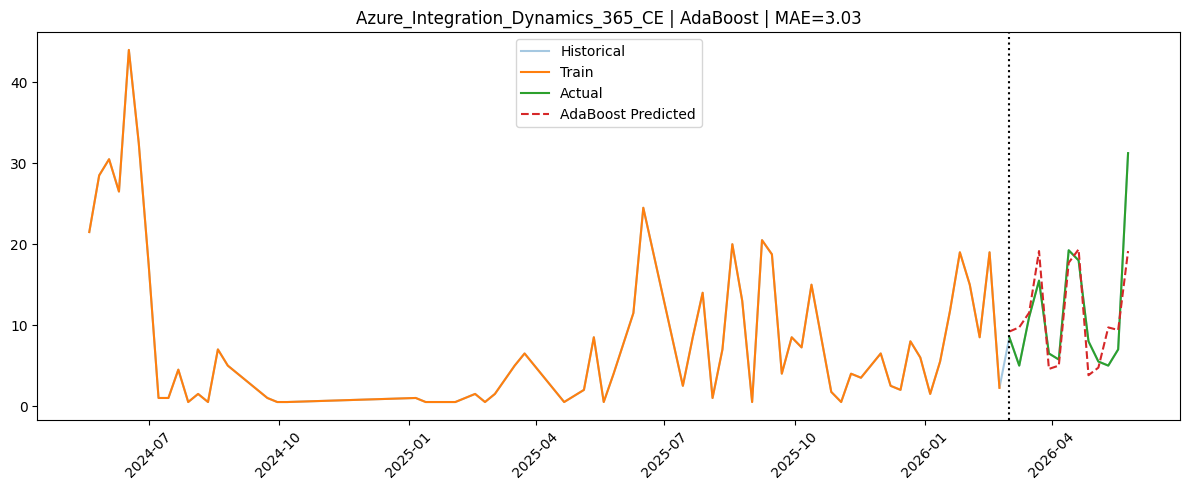

Saved: saved_models\Azure_Integration__Dynamics_365_CE__AdaBoost.pkl


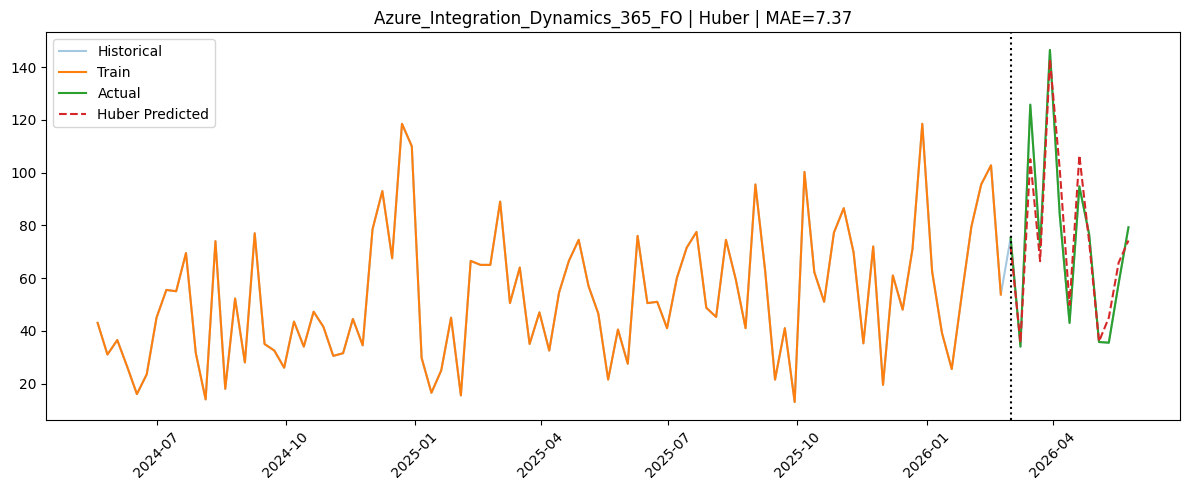

Saved: saved_models\Azure_Integration__Dynamics_365_FO__Huber.pkl


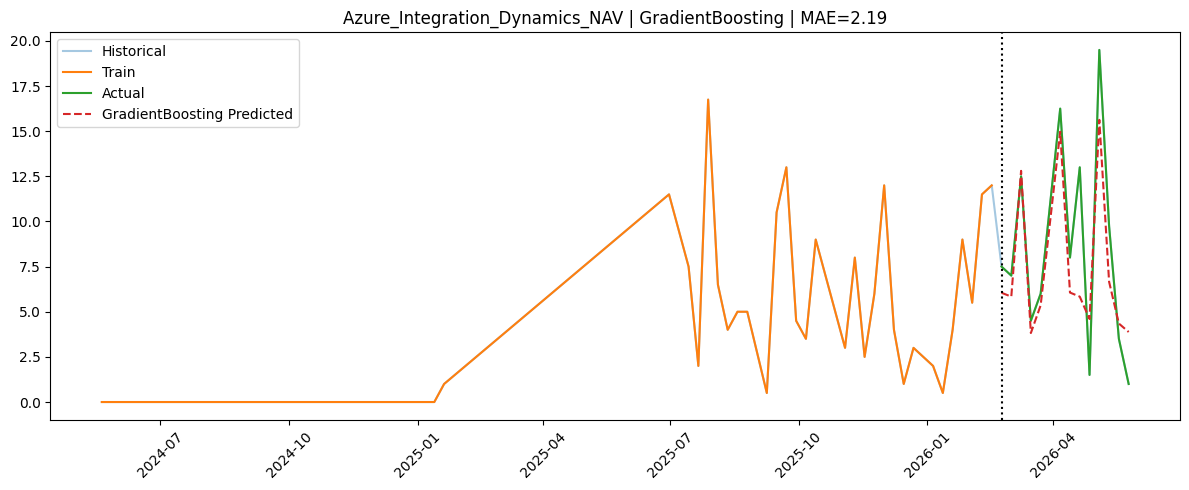

Saved: saved_models\Azure_Integration__Dynamics_NAV__GradientBoosting.pkl


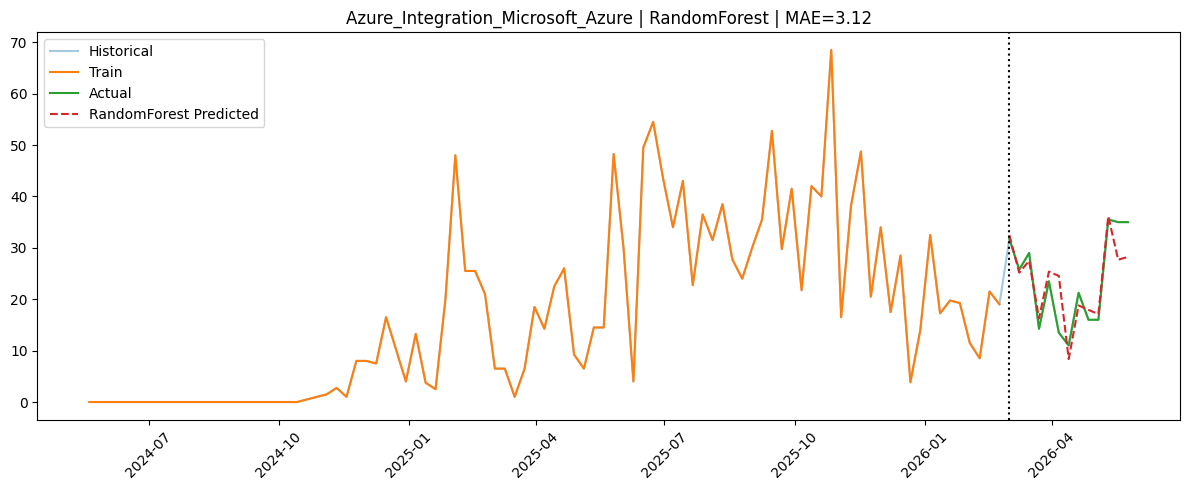

Saved: saved_models\Azure_Integration__Microsoft_Azure__RandomForest.pkl


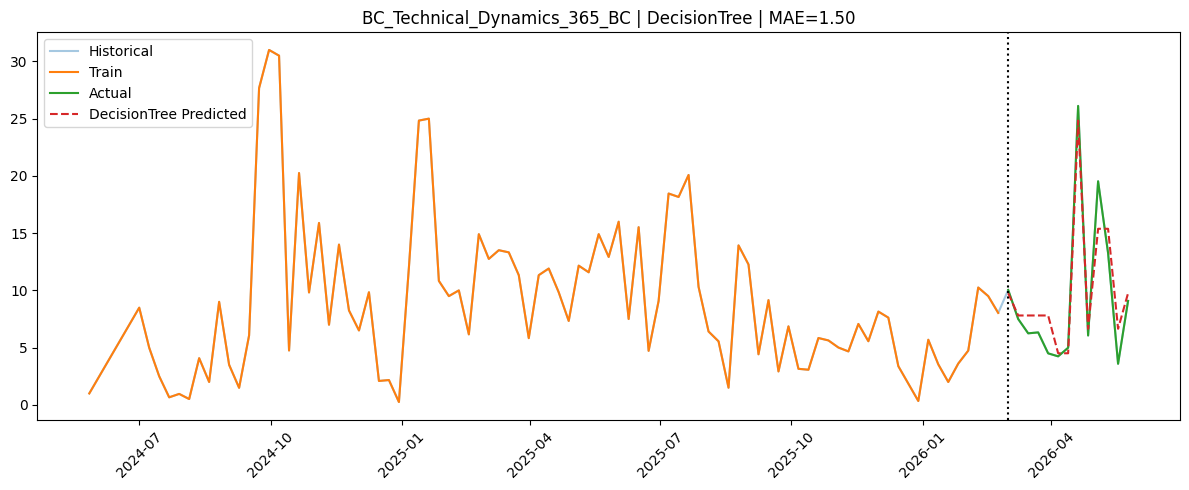

Saved: saved_models\BC_Technical__Dynamics_365_BC__DecisionTree.pkl


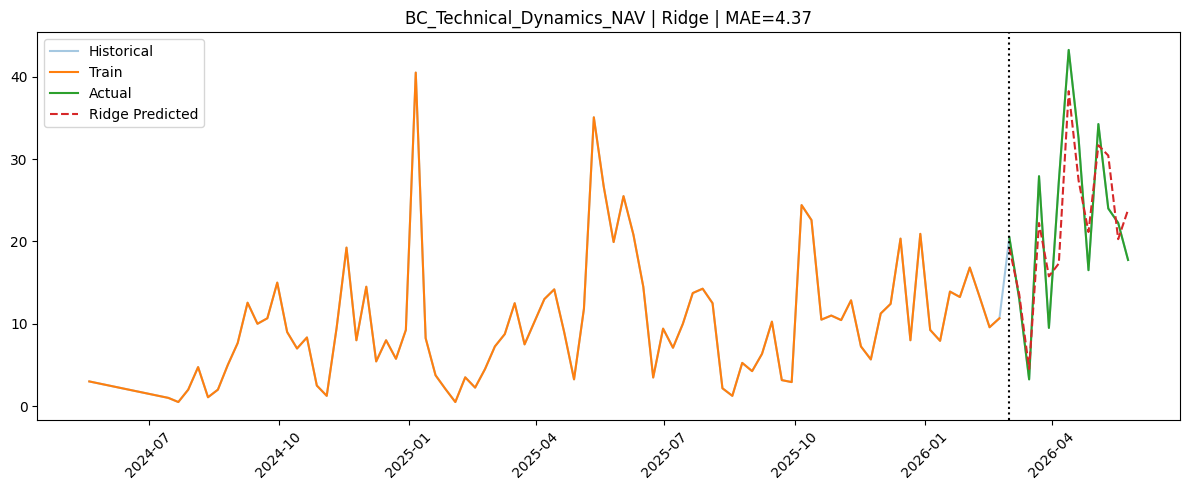

Saved: saved_models\BC_Technical__Dynamics_NAV__Ridge.pkl


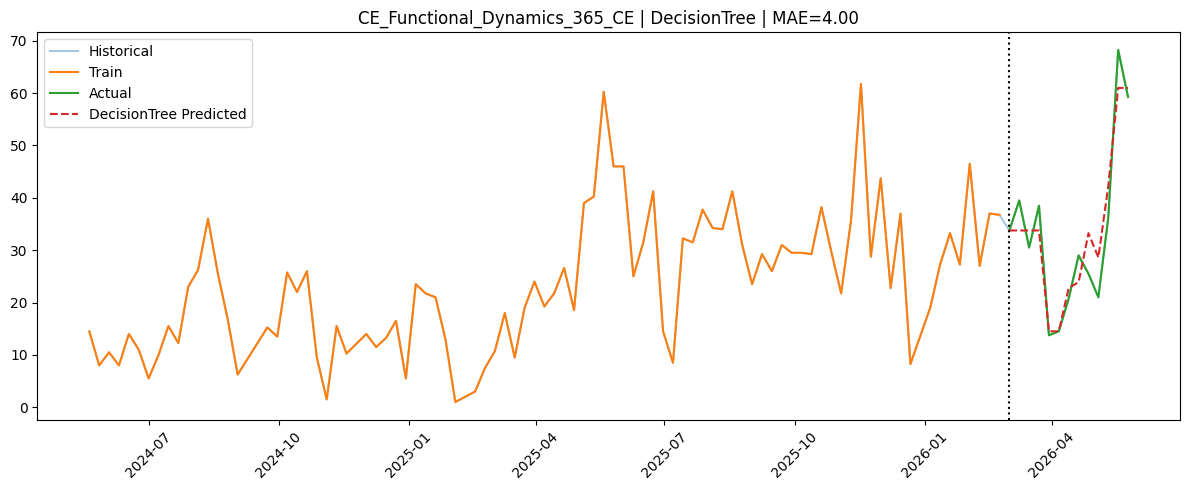

Saved: saved_models\CE_Functional__Dynamics_365_CE__DecisionTree.pkl


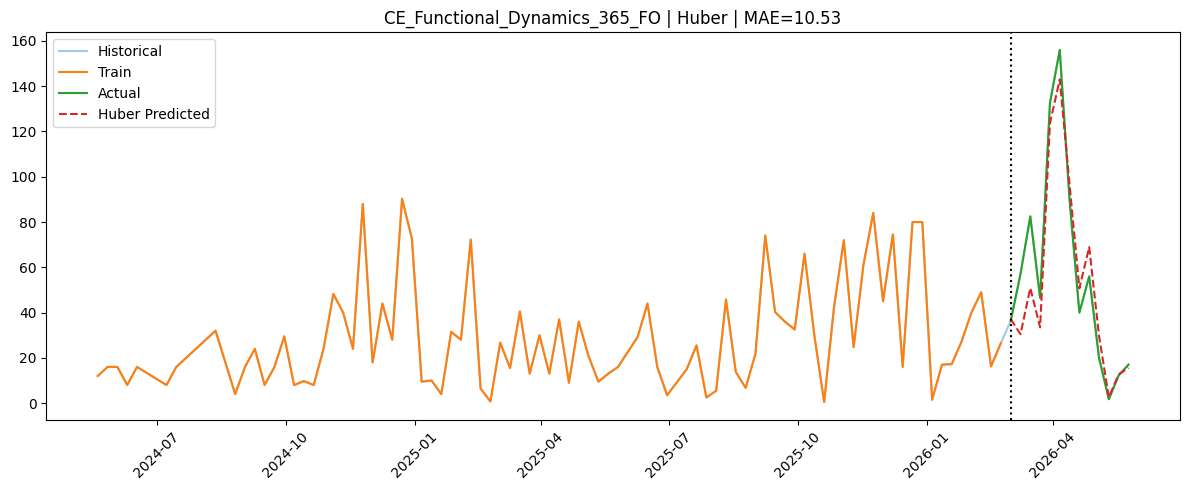

Saved: saved_models\CE_Functional__Dynamics_365_FO__Huber.pkl


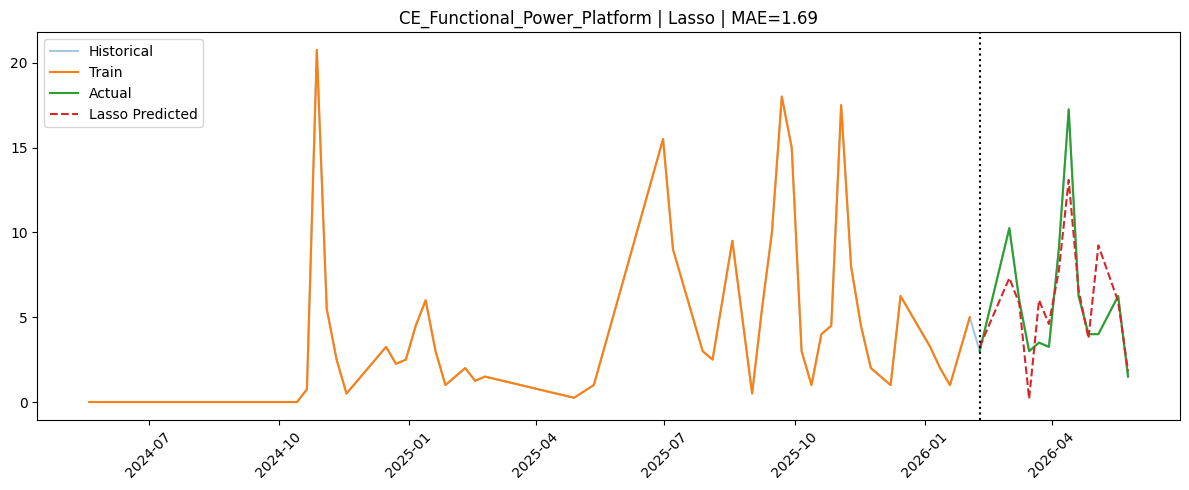

Saved: saved_models\CE_Functional__Power_Platform__Lasso.pkl


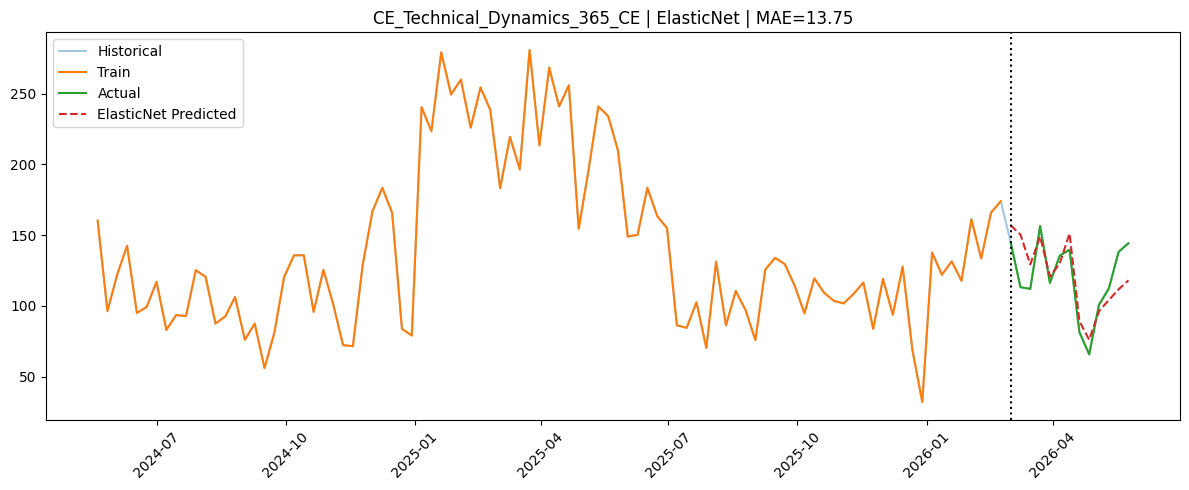

Saved: saved_models\CE_Technical__Dynamics_365_CE__ElasticNet.pkl


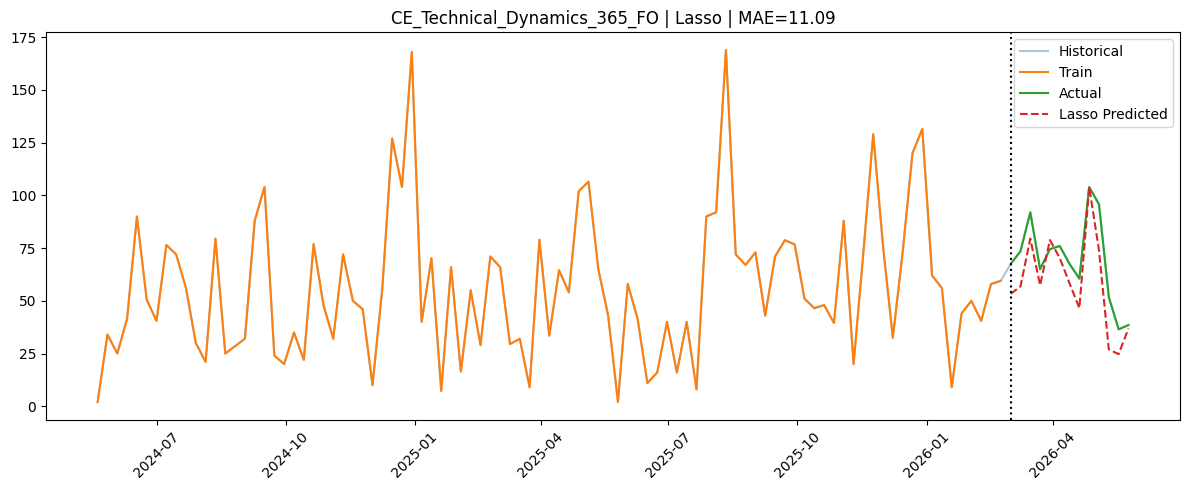

Saved: saved_models\CE_Technical__Dynamics_365_FO__Lasso.pkl


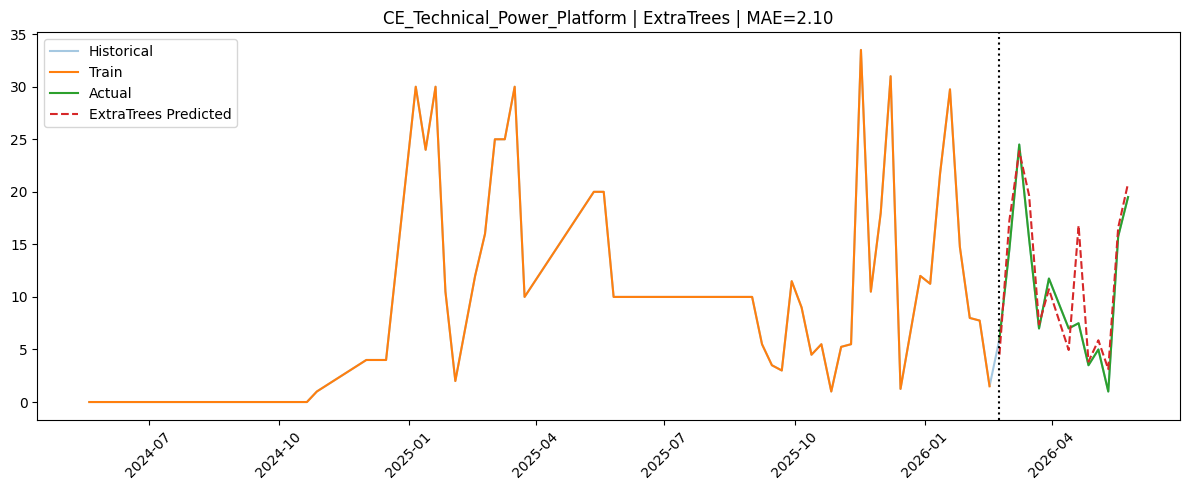

Saved: saved_models\CE_Technical__Power_Platform__ExtraTrees.pkl


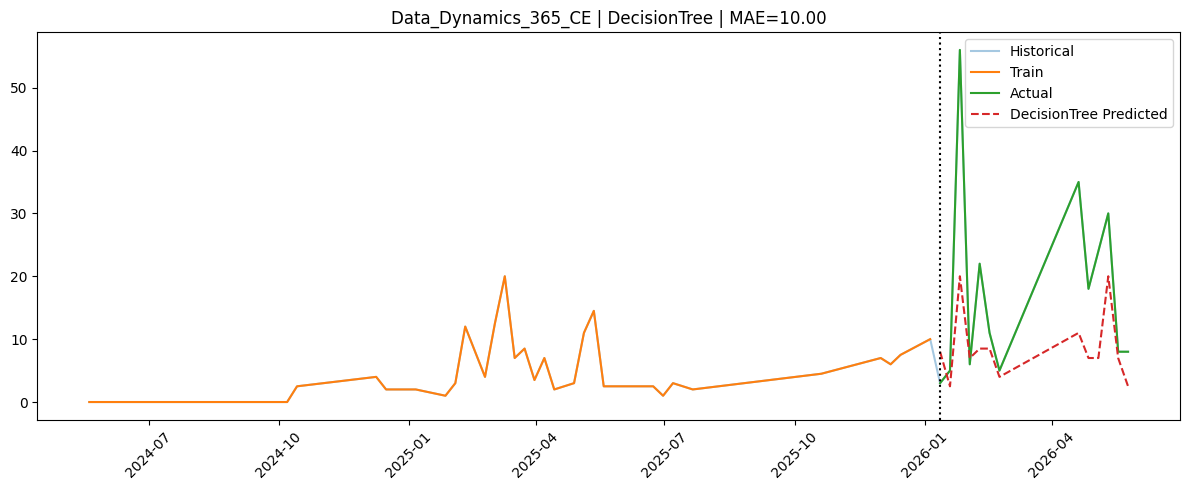

Saved: saved_models\Data_Dynamics__365_CE__DecisionTree.pkl


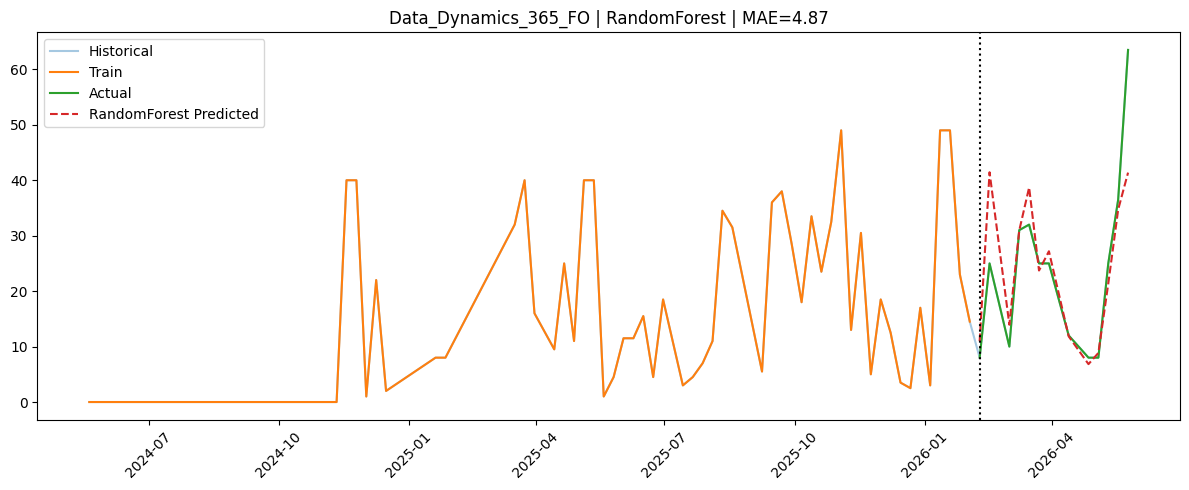

Saved: saved_models\Data_Dynamics__365_FO__RandomForest.pkl


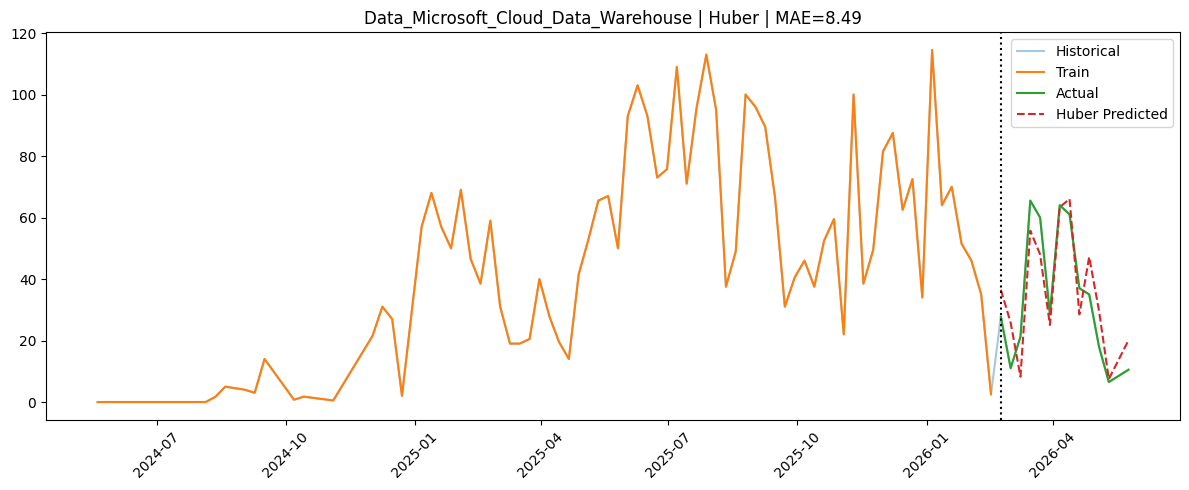

Saved: saved_models\Data_Microsoft__Cloud_Data_Warehouse__Huber.pkl


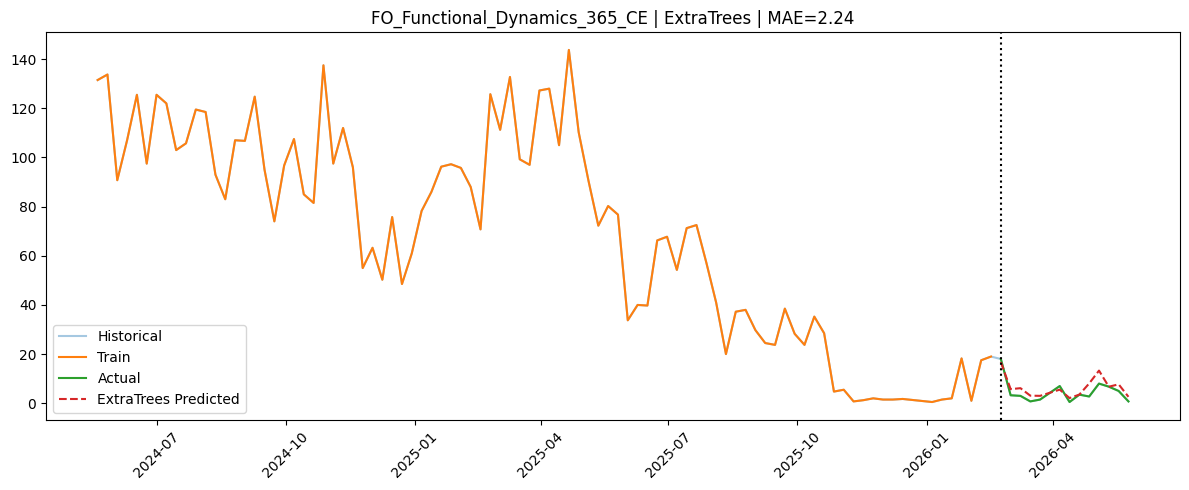

Saved: saved_models\FO_Functional__Dynamics_365_CE__ExtraTrees.pkl


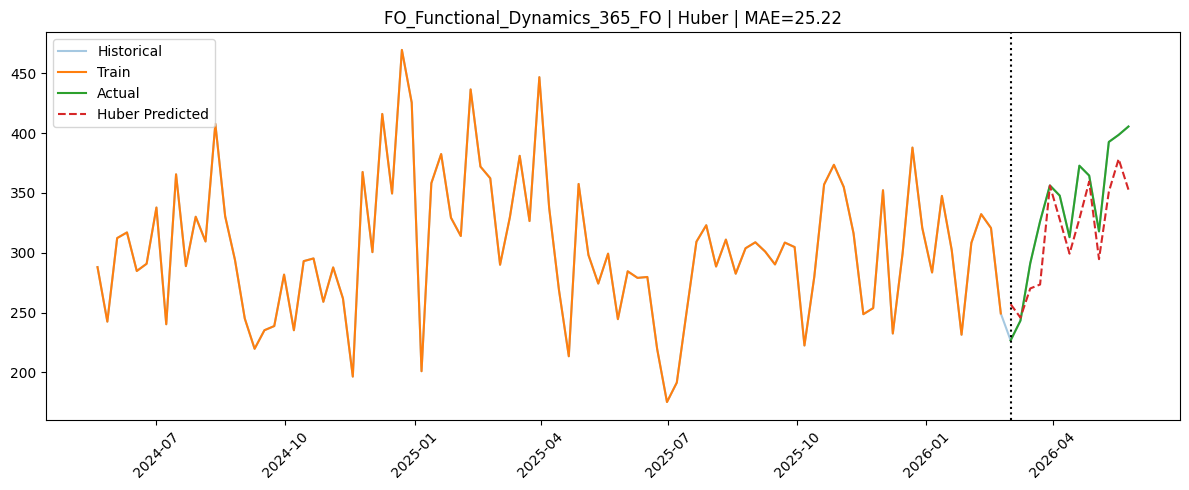

Saved: saved_models\FO_Functional__Dynamics_365_FO__Huber.pkl


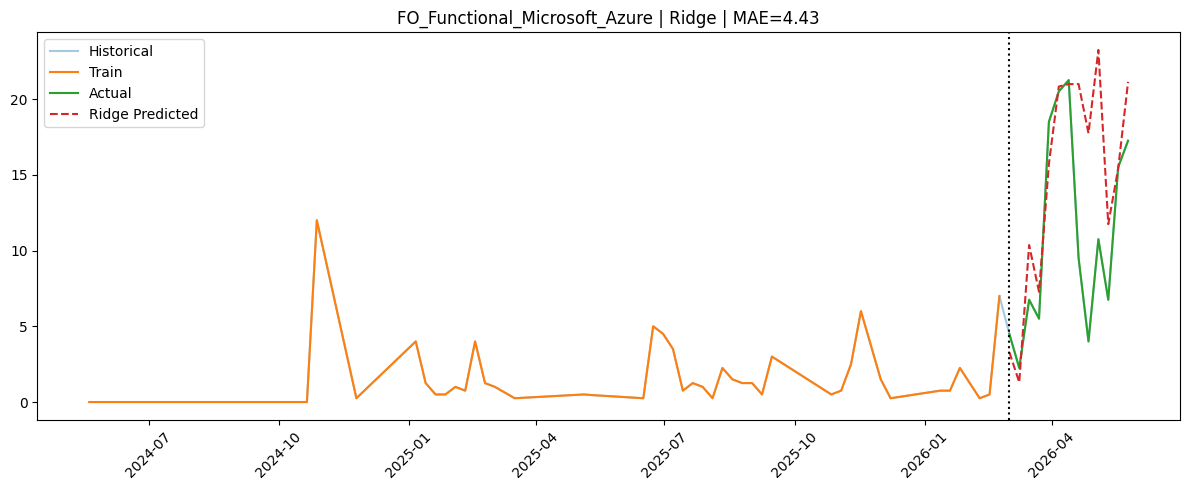

Saved: saved_models\FO_Functional__Microsoft_Azure__Ridge.pkl


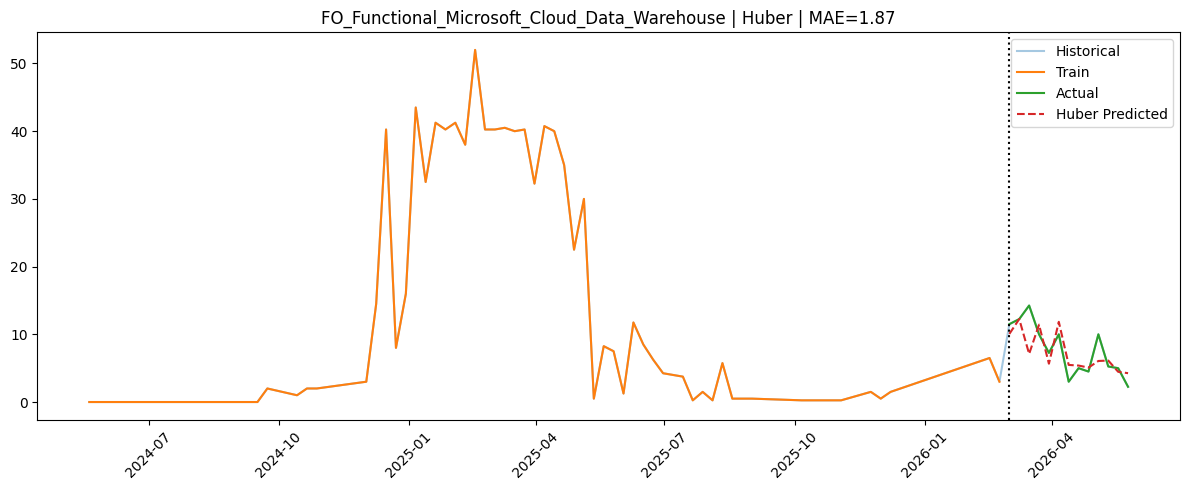

Saved: saved_models\FO_Functional__Microsoft_Cloud_Data_Warehouse__Huber.pkl


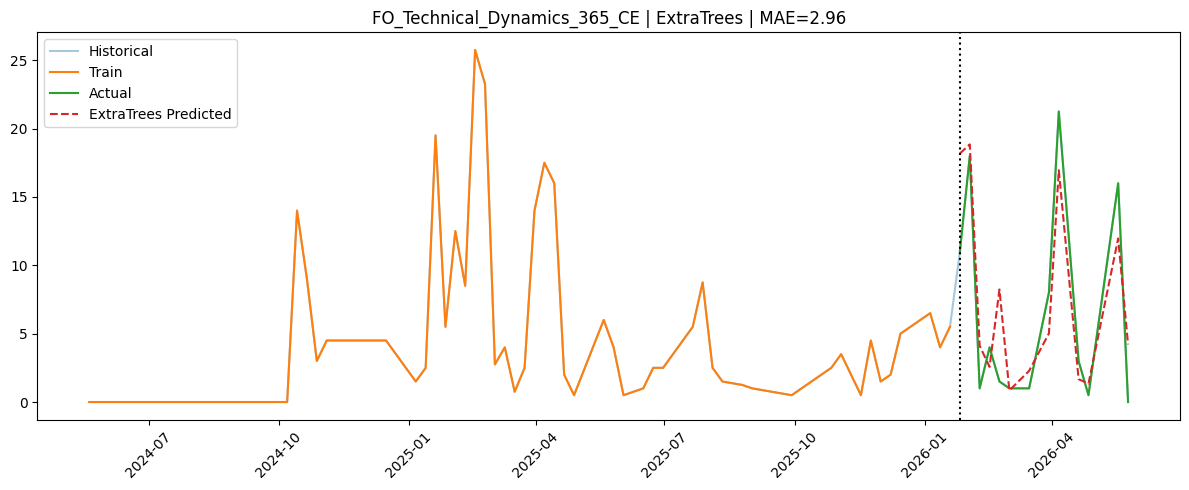

Saved: saved_models\FO_Technical__Dynamics_365_CE__ExtraTrees.pkl


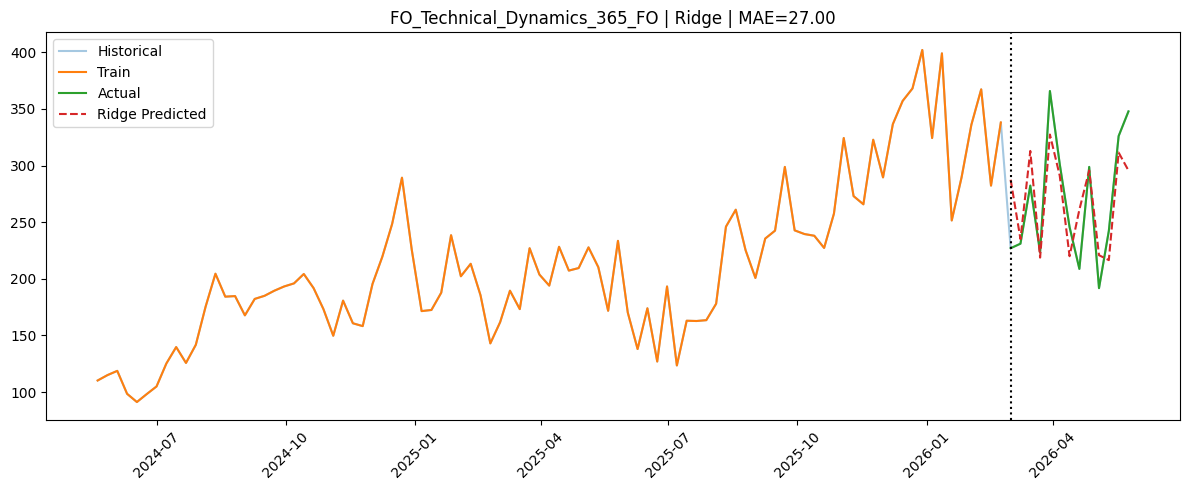

Saved: saved_models\FO_Technical__Dynamics_365_FO__Ridge.pkl


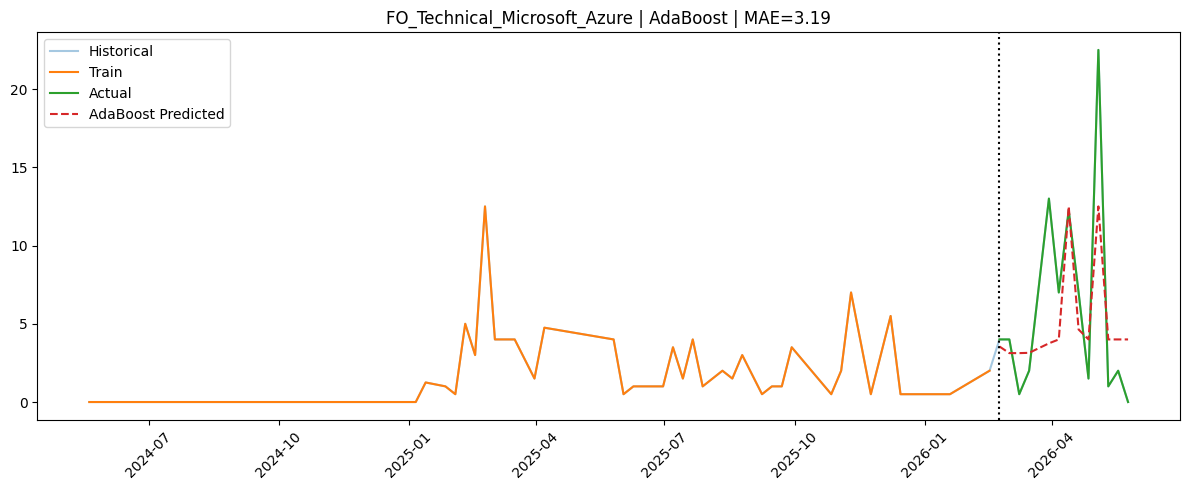

Saved: saved_models\FO_Technical__Microsoft_Azure__AdaBoost.pkl


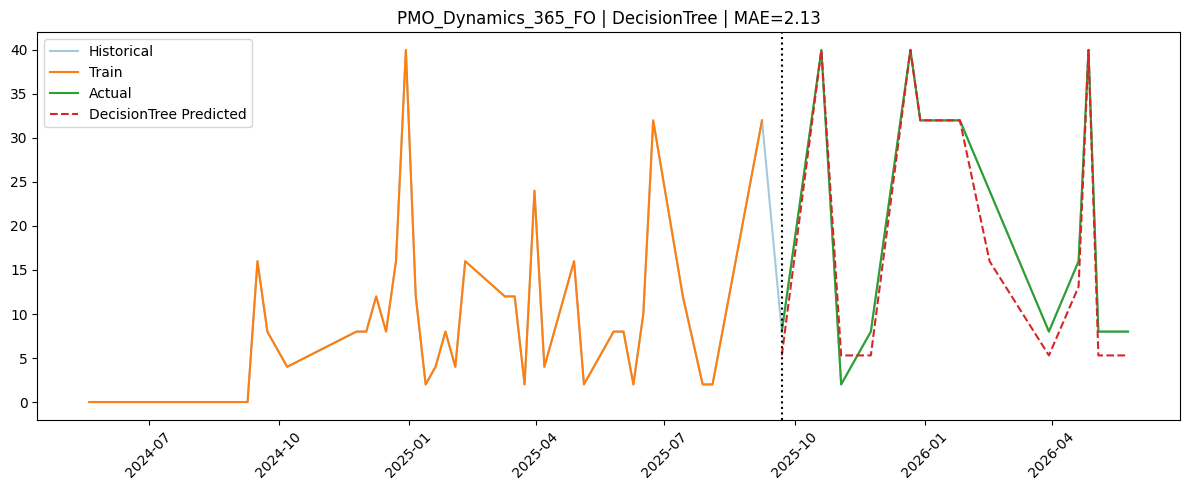

Saved: saved_models\PMO_Dynamics__365_FO__DecisionTree.pkl


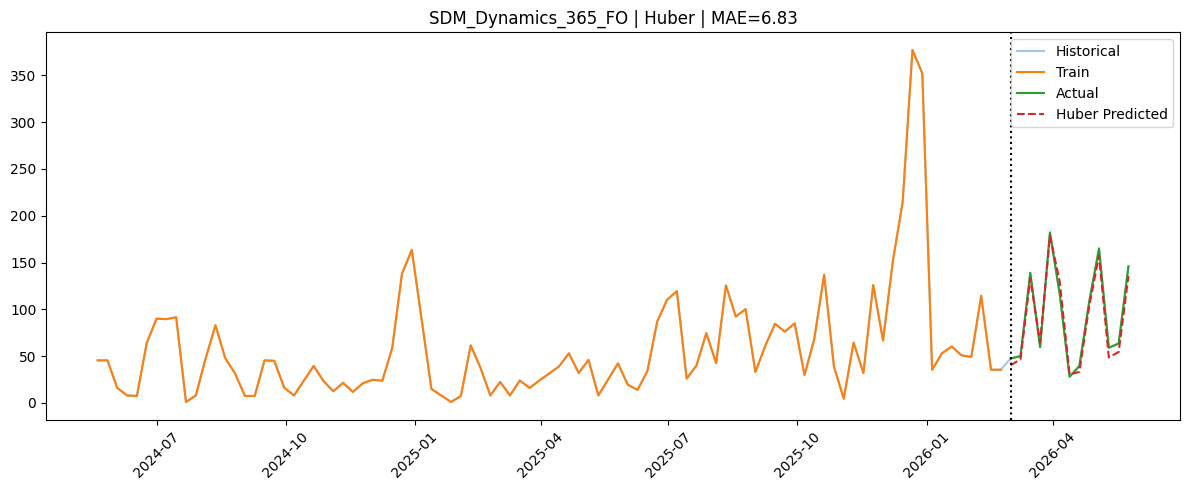

Saved: saved_models\SDM_Dynamics__365_FO__Huber.pkl


In [41]:
results_list = []
feature_importance_results = []

for group_name, df_group in grouped_dfs.items():

    df_group, X, y = build_features(df_group)

    if len(df_group[df_group["Time worked"] > 0]) < 30:
        continue

    if df_group["week"].max() != global_end:
        continue

    recent_4 = df_group.nlargest(4, "week")
    if recent_4["Time worked"].sum() <= 0:
        continue

    test_size = 13
    split_idx = len(df_group) - test_size

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]

    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    (
        model_results,
        best_model,
        best_preds,
        best_name,
        best_mae,
        best_mape
    ) = find_best_model(
        group_name,
        X_train,
        X_test,
        y_train,
        y_test,
        len(df_group)
    )

    results_list.extend(model_results)

    plot_predictions(
        group_name,
        df_group,
        y,
        y_train,
        y_test,
        best_preds,
        best_name,
        best_mae,
        split_idx
    )

    importance_df = generate_xgb_explainability(
        group_name,
        X_train,
        y_train,
        shap_dir
    )

    feature_importance_results.append(
        importance_df
    )

    save_model(
        group_name,
        best_model,
        X,
        y,
        df_group,
        best_name,
        best_mae,
        best_mape,
        model_dir
    )

## Build Inference Pipeline

In [42]:
def forecast_future(
    model,
    features,
    history,
    future_inputs,
    horizon
):

    history = history.copy()

    predictions = []

    for step in range(horizon):

        row = {}

        # business features
        row["is_sick_or_holiday"] = future_inputs.iloc[step]["is_sick_or_holiday"]
        row["is_spike"] = future_inputs.iloc[step]["is_spike"]
        row["is_dip"] = future_inputs.iloc[step]["is_dip"]

        # autoregressive features
        row["lag_1"] = history[-1]
        row["lag_2"] = history[-2]
        row["rolling_4"] = np.mean(history[-4:])

        X_future = pd.DataFrame([row])

        # ensure feature order matches training
        X_future = X_future.reindex(
            columns=features,
            fill_value=0
        )

        pred = model.predict(X_future)[0]

        predictions.append(pred)

        # prediction becomes history
        history.append(pred)

    return predictions

In [43]:
all_forecasts = []

for model_file in Path("saved_models").glob("*.pkl"):

    with open(model_file, "rb") as f:
        pkg = pickle.load(f)

    if "last_week" not in pkg:
        print(f"Skipping {model_file.name}: no last_week found")
        continue

    last_week = pd.to_datetime(pkg["last_week"])

    future_weeks = pd.date_range(
        start=last_week + pd.Timedelta(weeks=1),
        periods=13,
        freq="W"
    )

    future_inputs = pd.DataFrame({
        "week": future_weeks
    })

    # Calendar features
    future_inputs["week_of_year"] = (
        future_inputs["week"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    future_inputs["month"] = (
        future_inputs["week"]
        .dt.month
    )

    future_inputs["is_month_end"] = (
        future_inputs["week"]
        .dt.is_month_end
        .astype(int)
    )

    future_inputs["is_quarter_end"] = (
        future_inputs["week"]
        .dt.is_quarter_end
        .astype(int)
    )

    # Unknown future business inputs
    future_inputs["is_leave"] = 0
    future_inputs["is_sick_or_holiday"] = 0
    future_inputs["is_spike"] = 0
    future_inputs["is_dip"] = 0

    preds = forecast_future(
        model=pkg["model"],
        features=pkg["features"],
        history=pkg["history"],
        future_inputs=future_inputs,
        horizon=13
    )

    row = {
        "specialisation": pkg["specialisation"],
        "technology": pkg["technology"],
    }


    for week_date, pred in zip(future_weeks, preds):
        row[week_date.strftime("%Y-%m-%d")] = pred

    row["pxn_dt"] = pd.Timestamp.today().date()

    all_forecasts.append(row)

predictions_df = pd.DataFrame(all_forecasts)

predictions_df.to_csv(
    f"predictions_demand_{pd.Timestamp.today().date()}.csv",
    index=False
)

display(predictions_df)

,specialisation,technology,2026-06-07,2026-06-14,2026-06-21,2026-06-28,2026-07-05,2026-07-12,2026-07-19,2026-07-26,2026-08-02,2026-08-09,2026-08-16,2026-08-23,2026-08-30,pxn_dt
0,Azure_Infrastructure,Dynamics_365_FO,9.054822,8.411349,3.564350,3.367437,2.373908,1.666302,1.013089,0.793410,0.565420,0.386761,0.266103,0.199292,0.144368,2026-07-06
1,Azure_Integration,Dynamics_365_CE,20.972222,19.389706,15.164286,14.940476,15.000000,15.000000,14.620000,14.620000,14.940476,14.940476,14.620000,14.620000,14.940476,2026-07-06
2,Azure_Integration,Dynamics_365_FO,39.287974,36.909568,38.176542,35.550621,29.263226,27.591048,26.385582,24.721983,23.153124,22.262285,21.515589,20.820601,20.259429,2026-07-06
3,Azure_Integration,Dynamics_NAV,7.042884,4.883766,4.913173,4.964290,4.917456,4.964290,4.964290,4.964290,4.964290,4.964290,4.964290,4.964290,4.964290,2026-07-06
4,Azure_Integration,Microsoft_Azure,28.699793,31.341391,31.136580,29.522765,28.211699,28.108504,28.108504,28.108504,28.108504,28.108504,28.108504,28.108504,28.108504,2026-07-06
5,BC_Technical,Dynamics_365_BC,11.018000,7.390000,7.390000,7.390000,7.390000,7.390000,7.390000,7.390000,7.390000,7.390000,7.390000,7.390000,7.390000,2026-07-06
6,BC_Technical,Dynamics_NAV,26.312155,23.707100,20.948794,21.708553,24.100796,22.673187,21.624800,22.518277,23.081014,22.303263,22.064658,22.536200,22.565398,2026-07-06
7,CE_Functional,Dynamics_365_CE,59.250000,46.000000,46.000000,46.000000,46.000000,59.250000,46.000000,46.000000,46.000000,46.000000,59.250000,46.000000,46.000000,2026-07-06
8,CE_Functional,Dynamics_365_FO,4.825093,3.326828,4.163902,3.854656,3.085995,2.989513,3.018899,2.964785,2.913522,2.906258,2.904937,2.899267,2.895670,2026-07-06
9,CE_Functional,Power_Platform,2.829146,4.510047,4.106238,2.578281,3.150817,3.946246,3.486500,2.907432,3.231528,3.517954,3.217893,2.992799,3.157103,2026-07-06
